# Car Market Trends Analysis - Car Dekho
**Columns:** Car_Name, Year, Selling_Price, Present_Price, Kms_Driven, Fuel_Type, Seller_Type, Transmission, Owner

## Step 1: Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10, 6)
sns.set_theme(style='darkgrid', palette='Set2')
print('Libraries imported!')

Libraries imported!


## Step 2: Load Dataset

In [2]:
df = pd.read_csv('car_Dekho_DA.csv')
print(f'Shape: {df.shape}')
df.head(10)

Shape: (301, 9)


,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0
5,vitara brezza,2018,9.25,9.83,2071,Diesel,Dealer,Manual,0
6,ciaz,2015,6.75,8.12,18796,Petrol,Dealer,Manual,0
7,s cross,2015,6.50,8.61,33429,Diesel,Dealer,Manual,0
8,ciaz,2016,8.75,8.89,20273,Diesel,Dealer,Manual,0
9,ciaz,2015,7.45,8.92,42367,Diesel,Dealer,Manual,0


## Step 3: Data Exploration

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 30.0 KB


In [4]:
df.describe().round(2)

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.00,301.00,301.00,301.00,301.00
mean,2013.63,4.66,7.63,36947.21,0.04
std,2.89,5.08,8.64,38886.88,0.25
min,2003.00,0.10,0.32,500.00,0.00
25%,2012.00,0.90,1.20,15000.00,0.00
50%,2014.00,3.60,6.40,32000.00,0.00
75%,2016.00,6.00,9.90,48767.00,0.00
max,2018.00,35.00,92.60,500000.00,3.00


In [5]:
print('Missing Values:')
print(df.isnull().sum())
print(f'\nDuplicates: {df.duplicated().sum()}')
for col in ['Fuel_Type','Seller_Type','Transmission']:
    print(f'{col}: {df[col].unique()}')

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicates: 2
Fuel_Type: <ArrowStringArray>
['Petrol', 'Diesel', 'CNG']
Length: 3, dtype: str
Seller_Type: <ArrowStringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
Transmission: <ArrowStringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


## Step 4: Data Cleaning & Feature Engineering

In [6]:
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
df['Car_Age'] = 2024 - df['Year']
df['Price_Depreciation'] = df['Present_Price'] - df['Selling_Price']
df['Depreciation_pct'] = (df['Price_Depreciation'] / df['Present_Price'] * 100).round(2)
print(f'Clean shape: {df.shape}')
df[['Car_Name','Year','Car_Age','Selling_Price','Present_Price','Price_Depreciation','Depreciation_pct']].head()

Clean shape: (299, 12)


,Car_Name,Year,Car_Age,Selling_Price,Present_Price,Price_Depreciation,Depreciation_pct
0,ritz,2014,10,3.35,5.59,2.24,40.07
1,sx4,2013,11,4.75,9.54,4.79,50.21
2,ciaz,2017,7,7.25,9.85,2.60,26.40
3,wagon r,2011,13,2.85,4.15,1.30,31.33
4,swift,2014,10,4.60,6.87,2.27,33.04


## Step 5: Distribution of Numerical Features

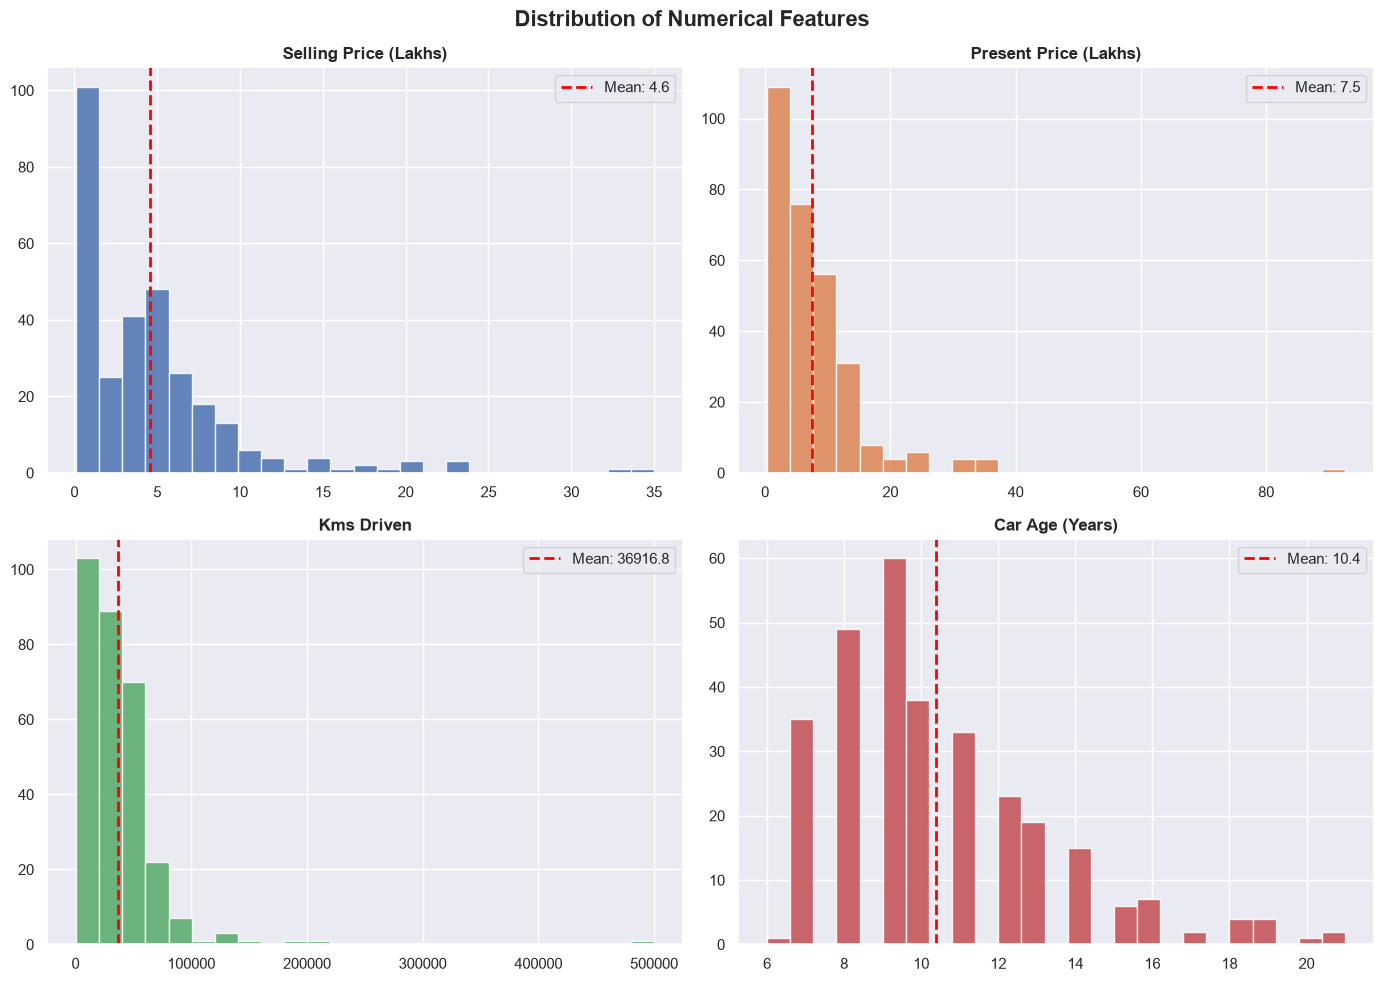

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14,10))
fig.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold')
cols = ['Selling_Price','Present_Price','Kms_Driven','Car_Age']
titles = ['Selling Price (Lakhs)','Present Price (Lakhs)','Kms Driven','Car Age (Years)']
colors = ['#4C72B0','#DD8452','#55A868','#C44E52']
for ax, col, title, color in zip(axes.flatten(), cols, titles, colors):
    ax.hist(df[col], bins=25, color=color, edgecolor='white', alpha=0.85)
    ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.legend()
plt.tight_layout()
plt.show()

## Step 6: Categorical Variables Distribution

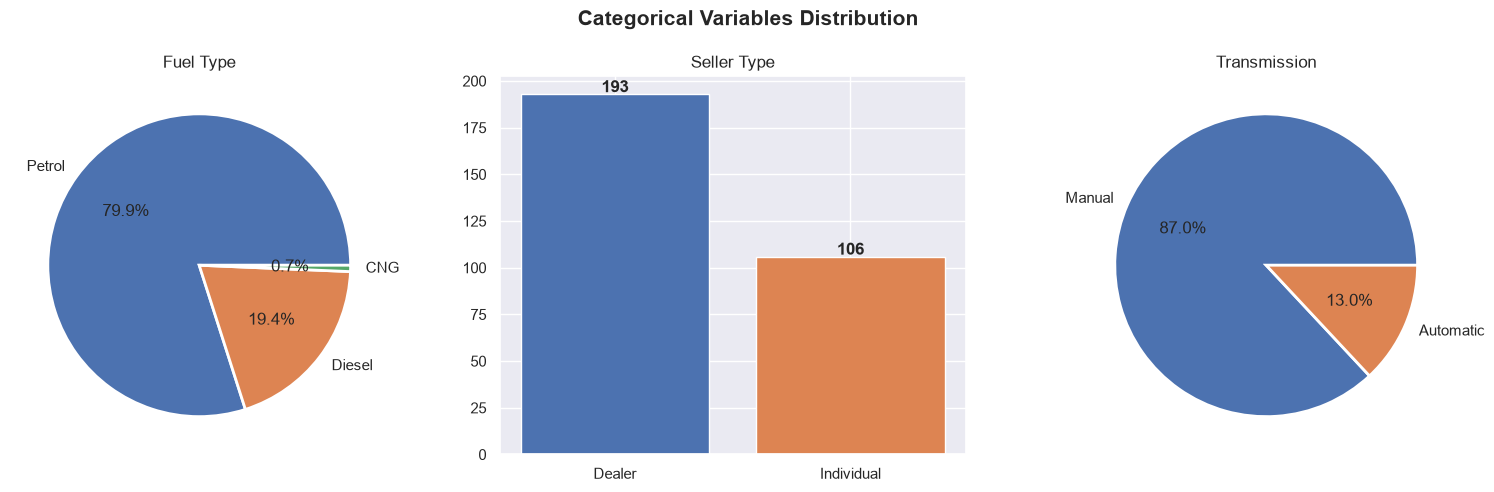

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16,5))
fig.suptitle('Categorical Variables Distribution', fontsize=15, fontweight='bold')
fuel = df['Fuel_Type'].value_counts()
axes[0].pie(fuel, labels=fuel.index, autopct='%1.1f%%', colors=['#4C72B0','#DD8452','#55A868'],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Fuel Type')
seller = df['Seller_Type'].value_counts()
axes[1].bar(seller.index, seller.values, color=['#4C72B0','#DD8452'], edgecolor='white')
for i, v in enumerate(seller.values):
    axes[1].text(i, v+1, str(v), ha='center', fontweight='bold')
axes[1].set_title('Seller Type')
trans = df['Transmission'].value_counts()
axes[2].pie(trans, labels=trans.index, autopct='%1.1f%%', colors=['#4C72B0','#DD8452'],
            wedgeprops=dict(edgecolor='white', linewidth=2))
axes[2].set_title('Transmission')
plt.tight_layout()
plt.show()

## Step 7: Year-wise Trends

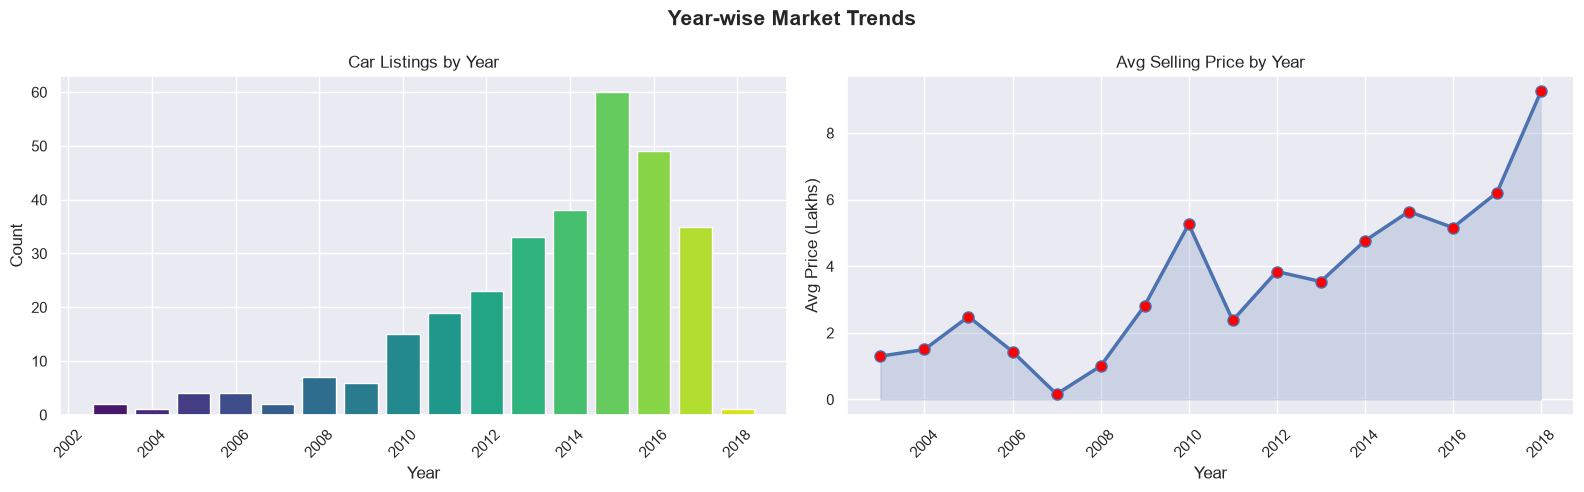

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
fig.suptitle('Year-wise Market Trends', fontsize=15, fontweight='bold')
yc = df['Year'].value_counts().sort_index()
axes[0].bar(yc.index, yc.values, color=sns.color_palette('viridis', len(yc)), edgecolor='white')
axes[0].set_title('Car Listings by Year')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)
yp = df.groupby('Year')['Selling_Price'].mean()
axes[1].plot(yp.index, yp.values, marker='o', color='#4C72B0', linewidth=2.5, markersize=8, markerfacecolor='red')
axes[1].fill_between(yp.index, yp.values, alpha=0.2, color='#4C72B0')
axes[1].set_title('Avg Selling Price by Year')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Avg Price (Lakhs)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Step 8: Fuel Type vs Selling Price

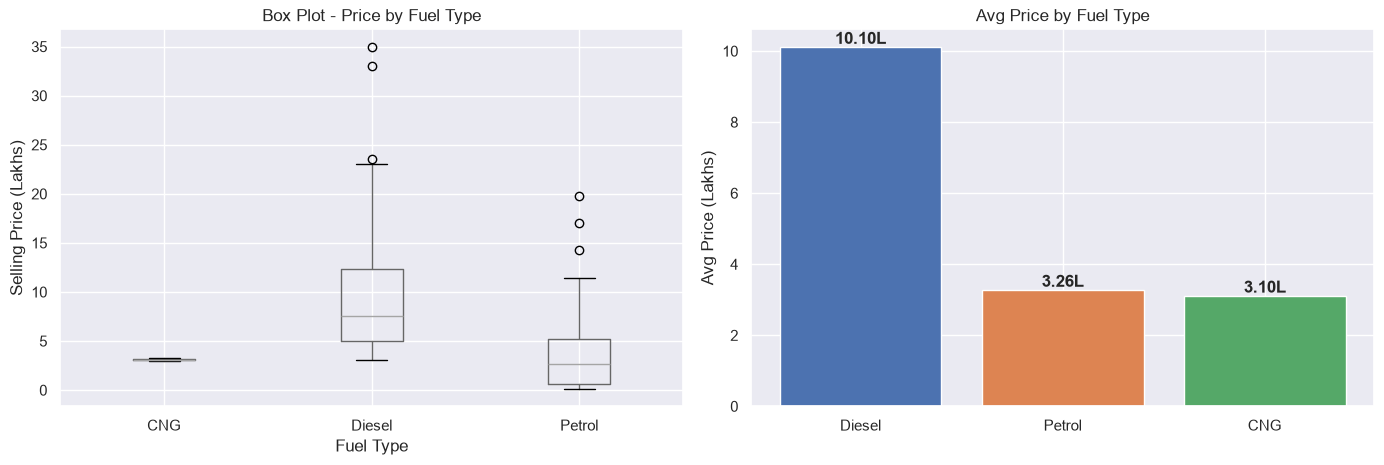

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Selling Price by Fuel Type', fontsize=15, fontweight='bold')
df.boxplot(column='Selling_Price', by='Fuel_Type', ax=axes[0])
plt.sca(axes[0])
plt.suptitle('')
axes[0].set_title('Box Plot - Price by Fuel Type')
axes[0].set_xlabel('Fuel Type')
axes[0].set_ylabel('Selling Price (Lakhs)')
avg = df.groupby('Fuel_Type')['Selling_Price'].mean().sort_values(ascending=False)
axes[1].bar(avg.index, avg.values, color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
for i, v in enumerate(avg.values):
    axes[1].text(i, v+0.1, f'{v:.2f}L', ha='center', fontweight='bold')
axes[1].set_title('Avg Price by Fuel Type')
axes[1].set_ylabel('Avg Price (Lakhs)')
plt.tight_layout()
plt.show()

## Step 9: Transmission and Seller Type vs Price

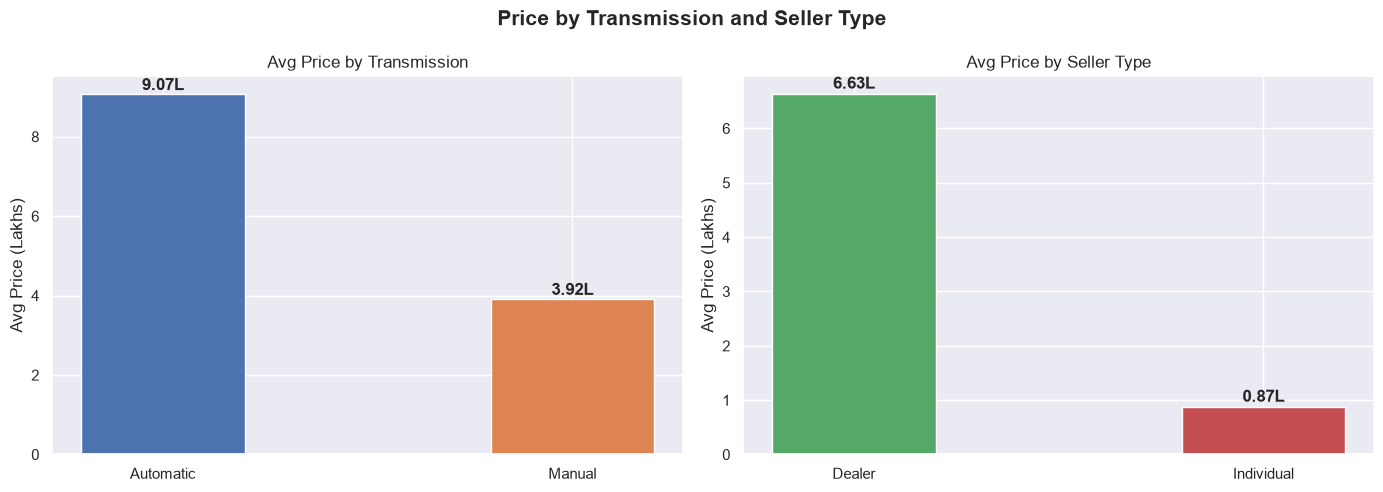

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Price by Transmission and Seller Type', fontsize=15, fontweight='bold')
at = df.groupby('Transmission')['Selling_Price'].mean()
axes[0].bar(at.index, at.values, color=['#4C72B0','#DD8452'], edgecolor='white', width=0.4)
for i, v in enumerate(at.values):
    axes[0].text(i, v+0.1, f'{v:.2f}L', ha='center', fontweight='bold')
axes[0].set_title('Avg Price by Transmission')
axes[0].set_ylabel('Avg Price (Lakhs)')
as_ = df.groupby('Seller_Type')['Selling_Price'].mean()
axes[1].bar(as_.index, as_.values, color=['#55A868','#C44E52'], edgecolor='white', width=0.4)
for i, v in enumerate(as_.values):
    axes[1].text(i, v+0.1, f'{v:.2f}L', ha='center', fontweight='bold')
axes[1].set_title('Avg Price by Seller Type')
axes[1].set_ylabel('Avg Price (Lakhs)')
plt.tight_layout()
plt.show()

## Step 10: Price Depreciation Analysis

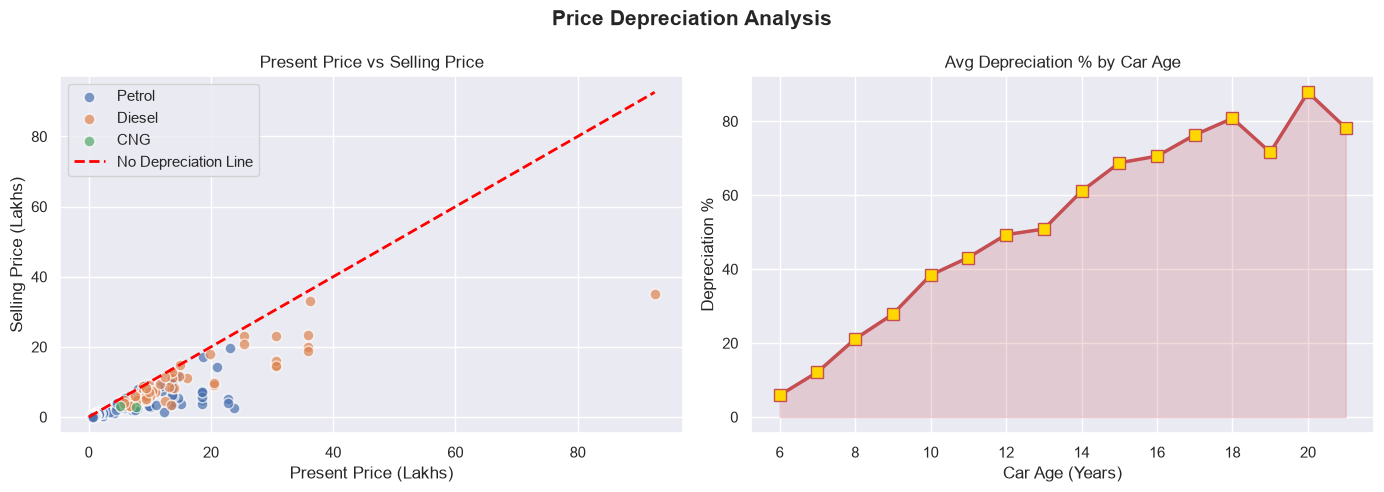

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Price Depreciation Analysis', fontsize=15, fontweight='bold')
cmap = {'Petrol':'#4C72B0','Diesel':'#DD8452','CNG':'#55A868'}
for fuel in df['Fuel_Type'].unique():
    s = df[df['Fuel_Type']==fuel]
    axes[0].scatter(s['Present_Price'], s['Selling_Price'], label=fuel,
                    color=cmap.get(fuel,'gray'), alpha=0.7, s=60, edgecolors='white')
mp = df['Present_Price'].max()
axes[0].plot([0,mp],[0,mp],'r--', linewidth=2, label='No Depreciation Line')
axes[0].set_title('Present Price vs Selling Price')
axes[0].set_xlabel('Present Price (Lakhs)')
axes[0].set_ylabel('Selling Price (Lakhs)')
axes[0].legend()
ad = df.groupby('Car_Age')['Depreciation_pct'].mean().reset_index()
axes[1].plot(ad['Car_Age'], ad['Depreciation_pct'], marker='s', color='#C44E52',
             linewidth=2.5, markersize=8, markerfacecolor='gold')
axes[1].fill_between(ad['Car_Age'], ad['Depreciation_pct'], alpha=0.2, color='#C44E52')
axes[1].set_title('Avg Depreciation % by Car Age')
axes[1].set_xlabel('Car Age (Years)')
axes[1].set_ylabel('Depreciation %')
plt.tight_layout()
plt.show()

## Step 11: Correlation Heatmap

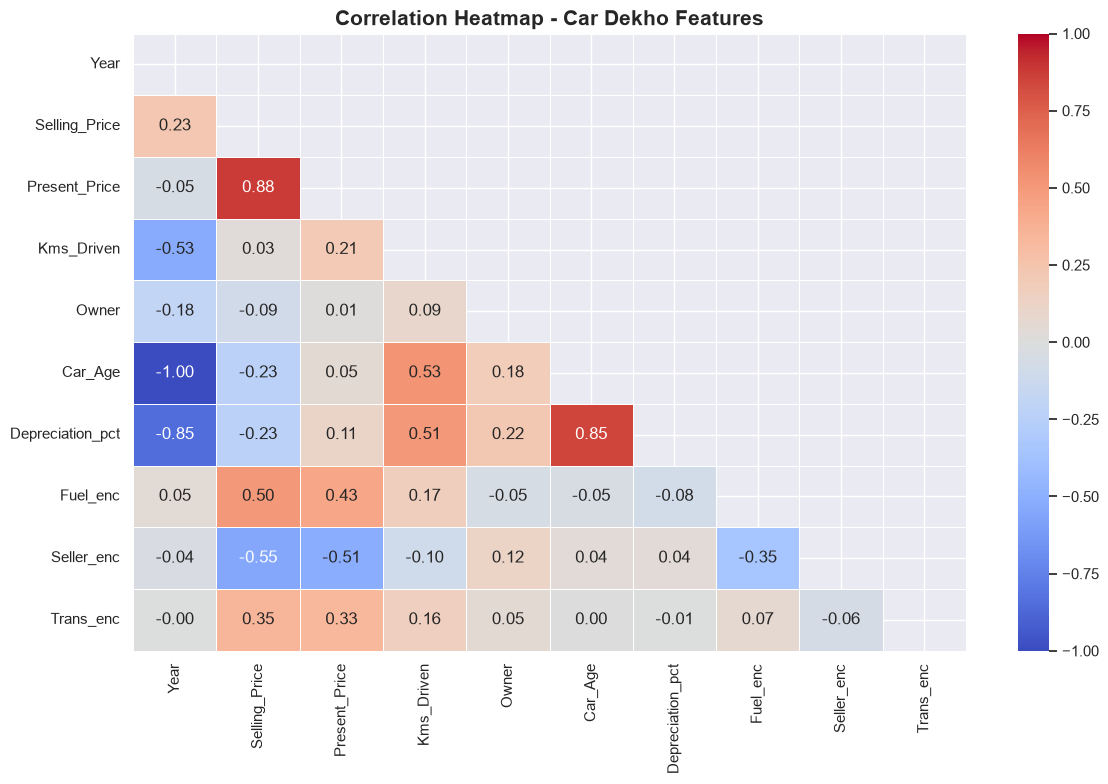

In [13]:
dfe = df.copy()
dfe['Fuel_enc'] = dfe['Fuel_Type'].map({'Petrol':0,'Diesel':1,'CNG':2})
dfe['Seller_enc'] = dfe['Seller_Type'].map({'Dealer':0,'Individual':1})
dfe['Trans_enc'] = dfe['Transmission'].map({'Manual':0,'Automatic':1})
cols = ['Year','Selling_Price','Present_Price','Kms_Driven','Owner',
        'Car_Age','Depreciation_pct','Fuel_enc','Seller_enc','Trans_enc']
cm = dfe[cols].corr()
plt.figure(figsize=(12,8))
mask = np.triu(np.ones_like(cm, dtype=bool))
sns.heatmap(cm, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap - Car Dekho Features', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 12: Top Cars Analysis

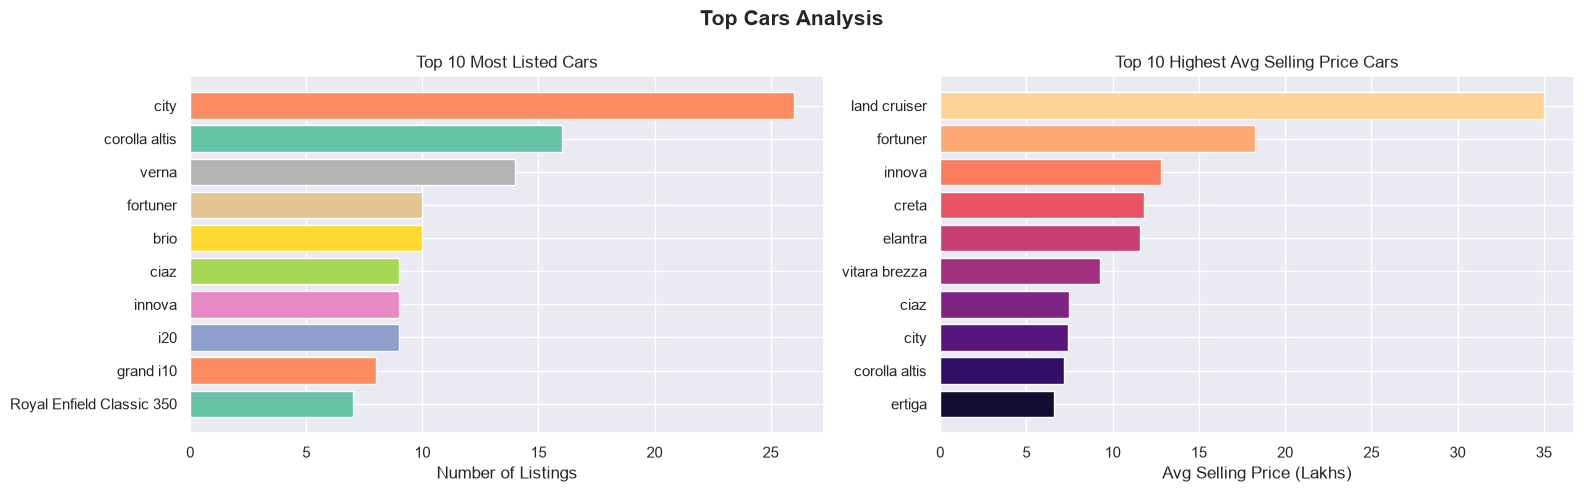

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(16,5))
fig.suptitle('Top Cars Analysis', fontsize=15, fontweight='bold')
tl = df['Car_Name'].value_counts().head(10)
axes[0].barh(tl.index[::-1], tl.values[::-1], color=sns.color_palette('Set2',10), edgecolor='white')
axes[0].set_title('Top 10 Most Listed Cars')
axes[0].set_xlabel('Number of Listings')
tp = df.groupby('Car_Name')['Selling_Price'].mean().sort_values(ascending=False).head(10)
axes[1].barh(tp.index[::-1], tp.values[::-1], color=sns.color_palette('magma',10), edgecolor='white')
axes[1].set_title('Top 10 Highest Avg Selling Price Cars')
axes[1].set_xlabel('Avg Selling Price (Lakhs)')
plt.tight_layout()
plt.show()

## Step 13: Kms Driven vs Selling Price

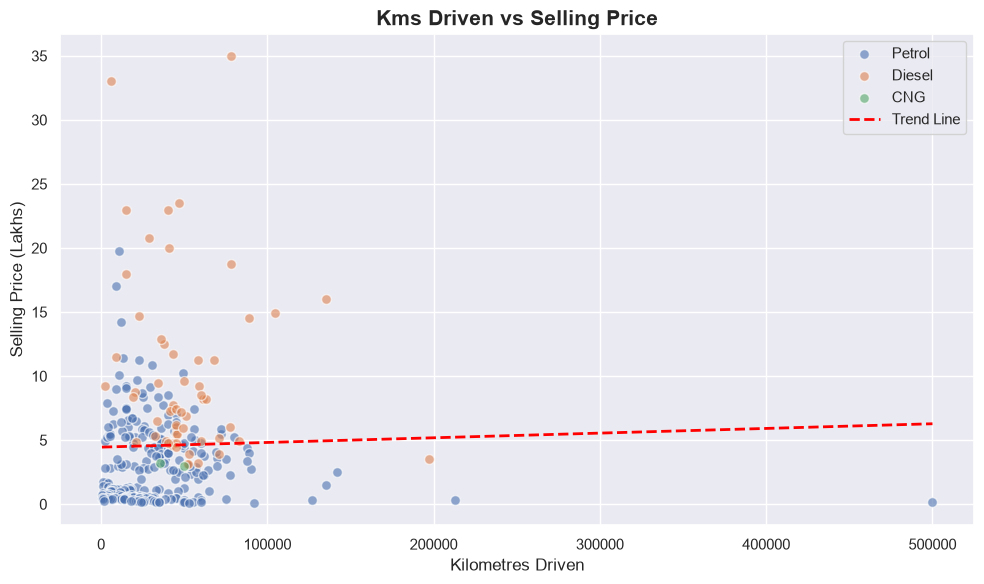

In [15]:
plt.figure(figsize=(10,6))
cmap = {'Petrol':'#4C72B0','Diesel':'#DD8452','CNG':'#55A868'}
for fuel in df['Fuel_Type'].unique():
    s = df[df['Fuel_Type']==fuel]
    plt.scatter(s['Kms_Driven'], s['Selling_Price'], label=fuel,
                color=cmap.get(fuel,'gray'), alpha=0.6, s=50, edgecolors='white')
z = np.polyfit(df['Kms_Driven'], df['Selling_Price'], 1)
p = np.poly1d(z)
xl = np.linspace(df['Kms_Driven'].min(), df['Kms_Driven'].max(), 200)
plt.plot(xl, p(xl), 'r--', linewidth=2, label='Trend Line')
plt.title('Kms Driven vs Selling Price', fontsize=15, fontweight='bold')
plt.xlabel('Kilometres Driven')
plt.ylabel('Selling Price (Lakhs)')
plt.legend()
plt.tight_layout()
plt.show()

## Step 14: Owner-wise Analysis

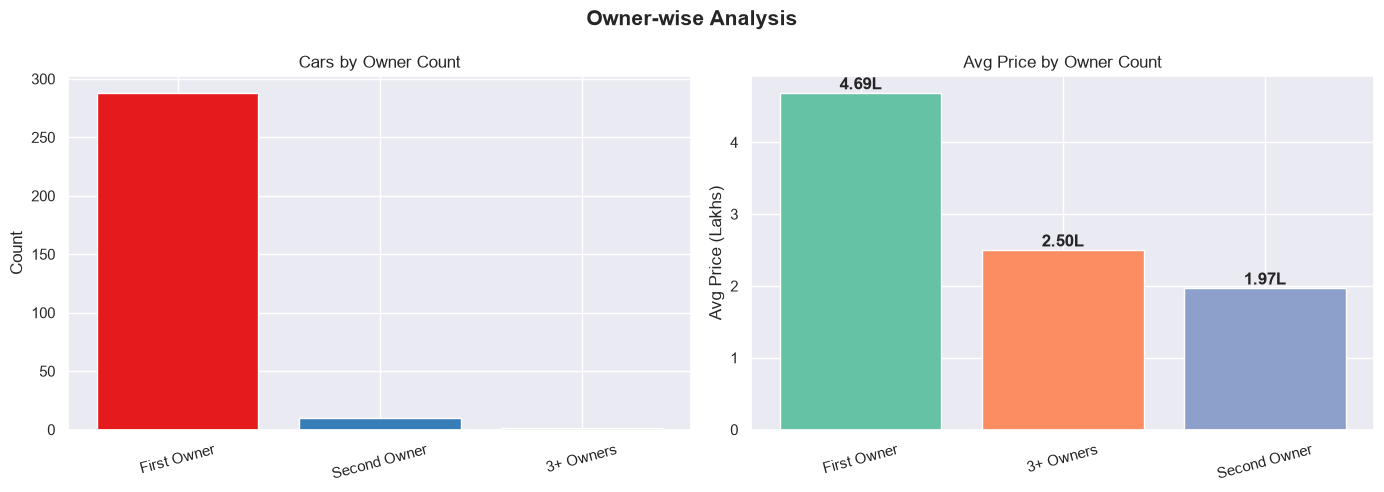

In [16]:
om = {0:'First Owner', 1:'Second Owner', 2:'Third Owner', 3:'3+ Owners'}
df['Owner_Label'] = df['Owner'].map(om).fillna('3+ Owners')
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Owner-wise Analysis', fontsize=15, fontweight='bold')
oc = df['Owner_Label'].value_counts()
axes[0].bar(oc.index, oc.values, color=sns.color_palette('Set1', len(oc)), edgecolor='white')
axes[0].set_title('Cars by Owner Count')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=15)
op = df.groupby('Owner_Label')['Selling_Price'].mean().sort_values(ascending=False)
axes[1].bar(op.index, op.values, color=sns.color_palette('Set2', len(op)), edgecolor='white')
for i, v in enumerate(op.values):
    axes[1].text(i, v+0.05, f'{v:.2f}L', ha='center', fontweight='bold')
axes[1].set_title('Avg Price by Owner Count')
axes[1].set_ylabel('Avg Price (Lakhs)')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

## Step 15: Key Insights and Conclusions

In [17]:
print('=' * 55)
print('   CAR DEKHO MARKET TRENDS - KEY INSIGHTS')
print('=' * 55)
print(f'Total Cars Analyzed      : {len(df)}')
print(f'Year Range               : {df["Year"].min()} - {df["Year"].max()}')
print(f'Avg Selling Price        : Rs {df["Selling_Price"].mean():.2f} Lakhs')
print(f'Max Selling Price        : Rs {df["Selling_Price"].max():.2f} Lakhs')
print(f'Most Common Fuel         : {df["Fuel_Type"].mode()[0]}')
print(f'Most Common Transmission : {df["Transmission"].mode()[0]}')
print(f'Most Common Seller       : {df["Seller_Type"].mode()[0]}')
print(f'Avg Depreciation         : {df["Depreciation_pct"].mean():.2f}%')
print(f'Most Listed Car          : {df["Car_Name"].mode()[0]}')
print(f'Avg Kms Driven           : {df["Kms_Driven"].mean():,.0f} km')
print(f'Avg Car Age              : {df["Car_Age"].mean():.1f} years')
print('=' * 55)

   CAR DEKHO MARKET TRENDS - KEY INSIGHTS
Total Cars Analyzed      : 299
Year Range               : 2003 - 2018
Avg Selling Price        : Rs 4.59 Lakhs
Max Selling Price        : Rs 35.00 Lakhs
Most Common Fuel         : Petrol
Most Common Transmission : Manual
Most Common Seller       : Dealer
Avg Depreciation         : 36.62%
Most Listed Car          : city
Avg Kms Driven           : 36,917 km
Avg Car Age              : 10.4 years


## Conclusions

1. **Petrol dominates** Car Dekho listings; CNG cars are rare.
2. **Newer cars** command significantly higher selling prices.
3. **Depreciation** is heavy in early years - average 30-60%.
4. **Automatic cars** sell at a premium over Manual transmission.
5. **Dealers** price cars higher than individual sellers.
6. **More kms driven = lower selling price** (negative correlation).
7. **First-owner cars** fetch the highest average selling price.
8. **Diesel cars** command a premium over Petrol in the used car market.

---
*Car Dekho Data Analysis - VOIS and Vodafone Idea Foundation Minor Project*